# Регрессия для IC50

Цель ноутбука - построить и сравнить несколько моделей регрессии для предсказания значения IC50, mM.

Используются результаты preprocessing:

- SF_ML_data_tree.pkl - набор признаков после удаления константных и высококоррелированных признаков, предназначенный для tree-based моделей;
- SF_ML_data_linear.pkl - набор признаков после дополнительной VIF-редукции, предназначенный для линейных моделей.

При моделировании IC50, mM из признакового пространства исключаются все целевые переменные: IC50, mM, CC50, mM и SI. Это необходимо для предотвращения утечки данных, поскольку SI = CC50 / IC50, а модель должна обучаться только на исходных молекулярных признаках, то есть RDKit-дескрипторах.

В рамках данной постановки предполагается, что при прогнозировании доступны только молекулярные дескрипторы. Поэтому другие экспериментальные или производные целевые показатели не используются как признаки.

In [1]:
import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor,
                              ExtraTreesRegressor,
                              GradientBoostingRegressor,
                              HistGradientBoostingRegressor)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (mean_absolute_error,
                             root_mean_squared_error,
                             median_absolute_error,
                             r2_score)

from scipy.stats import probplot, normaltest, skew, kurtosis

import warnings
warnings.filterwarnings('ignore')


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

TARGET = 'IC50, mM'
TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']

MODELS_DIR = 'models'

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)

## Загрузка подготовленных данных

In [3]:
def save_dataset(dataset, filename):
    dataset.to_pickle(f'{filename}.pkl')

def load_dataset(filename):
    return pd.read_pickle(f'{filename}.pkl')

In [4]:
df_tree = load_dataset('SF_ML_data_tree')
df_linear = load_dataset('SF_ML_data_linear')

print('df_tree shape:', df_tree.shape)
print('df_linear shape:', df_linear.shape)

display(df_tree.head())

df_tree shape: (966, 148)
df_linear shape: (966, 100)


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,Ipc,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA7,SlogP_VSA8,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,...,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_Ndealkylation1,fr_Ndealkylation2,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azo,fr_bicyclic,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,"IC50, mM","CC50, mM",SI
0,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,-0.293526,0.642857,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,2.187750e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,105.750639,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,6.239374,175.482382,28.125000
1,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,-0.313407,0.607143,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,2.187750e+06,10.633577,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,54.384066,97.951860,12.083682,0.000000,0.000000,0.000000,0.0,10.633577,33.495774,117.834321,13.089513,0.00000,0.0,10.633577,0.000000,0.0,25.173194,0.000000,33.495774,105.750639,0.0,0.0,24.06,0.0,0.0,0.0,0.000000,21.659962,23.919494,77.297729,...,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0.771831,5.402819,7.000000
2,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,-0.325573,0.562500,15.353938,9.681293,2.665274,-2.477203,2.679014,-2.565224,5.117187,-0.922902,3.214947,1.219066,8.610751e+06,8.966062,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,41.542423,74.032366,23.671624,53.363882,8.966062,0.000000,0.0,0.000000,33.495774,117.834321,41.280201,0.00000,0.0,0.000000,0.000000,0.0,62.329944,0.000000,33.495774,105.750639,0.0,0.0,0.00,0.0,0.0,0.0,0.000000,21.659962,23.919494,86.263791,...,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,3,0,223.808778,161.142320,0.720000
3,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,-0.293526,0.620690,14.821216,9.700497,2.600529,-2.342885,2.644709,-2.322030,5.944502,0.193510,3.179270,1.120513,3.572142e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,60.804888,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,112.171461,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,112.171461,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,70.629038,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,1.705624,107.855654,63.235294
4,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,-0.257239,0.600000,14.831112,9.700386,2.602486,-2.342009,2.64847

## Формирование целевой переменной и признаков

In [5]:
def split_features(df):
    return df[[col for col in df.columns if col not in TARGET_COLS]].copy(), df[TARGET].copy()

X_tree, y_tree = split_features(df_tree)

print('X_tree:', X_tree.shape)
print('y_tree:', y_tree.shape)

X_linear, y_linear = split_features(df_linear)

print('X_linear:', X_linear.shape)
print('y_linear:', y_linear.shape)

assert y_tree.equals(y_linear), 'Целевая переменная в df_tree и df_linear отличается.'

print('Минимальное IC50:', y_tree.min())
print('Максимальное IC50:', y_tree.max())


X_tree: (966, 145)
y_tree: (966,)
X_linear: (966, 97)
y_linear: (966,)
Минимальное IC50: 0.003516693745208505
Максимальное IC50: 4128.529376550779


### Логарифмирование целевой переменной

EDA показал сильную правостороннюю асимметрию распределения IC50, mM. Поэтому для стабилизации обучения и снижения влияния экстремально больших значений модели обучаются на преобразованной целевой переменной log1p(IC50). Итоговое качество дополнительно оценивается на исходной шкале после обратного преобразования expm1.

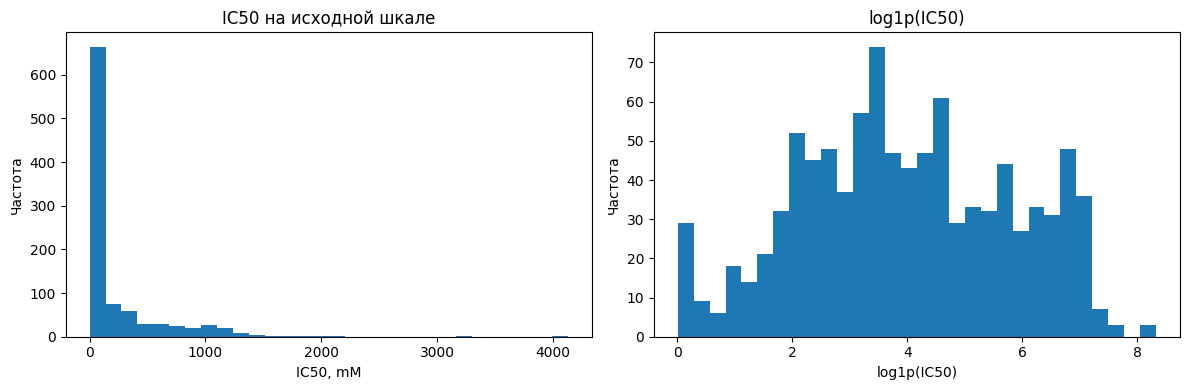

In [6]:
y_tree_log = np.log1p(y_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_tree, bins=30)
axes[0].set_title('IC50 на исходной шкале')
axes[0].set_xlabel('IC50, mM')
axes[0].set_ylabel('Частота')

axes[1].hist(y_tree_log, bins=30)
axes[1].set_title('log1p(IC50)')
axes[1].set_xlabel('log1p(IC50)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()


## Разделение данных на train и test выборки

Разделение выполняется один раз и одинаково для X_tree и X_linear, для корректного сравнения моделей.

In [7]:
train_idx, test_idx = train_test_split(np.arange(len(y_tree_log)),
                                       test_size=TEST_SIZE,
                                       random_state=RANDOM_STATE)

X_tree_train = X_tree.iloc[train_idx].copy()
X_tree_test = X_tree.iloc[test_idx].copy()

X_linear_train = X_linear.iloc[train_idx].copy()
X_linear_test = X_linear.iloc[test_idx].copy()

y_train = y_tree_log.iloc[train_idx].copy()
y_test = y_tree_log.iloc[test_idx].copy()

y_test_original = y_tree.iloc[test_idx].copy()

print('Train:', X_tree_train.shape[0])
print('Test:', X_tree_test.shape[0])


Train: 772
Test: 194


## Метрики качества

Для отбора моделей используется качество на логарифмированной шкале, так как именно на ней обучаются модели.

Дополнительно рассчитываются метрики на исходной шкале IC50, чтобы результат был интерпретируемым.

In [8]:
def regression_metrics(y_true, y_pred, prefix=''):
    return {f'{prefix}RMSE': root_mean_squared_error(y_true, y_pred),
            f'{prefix}MAE': mean_absolute_error(y_true, y_pred),
            f'{prefix}MedAE': median_absolute_error(y_true, y_pred),
            f'{prefix}R2': r2_score(y_true, y_pred)}


def evaluate_model(model, X_train, X_test, y_train_log, y_test_log, y_test_original, refit=True):
    if refit:
        model.fit(X_train, y_train_log)

    pred_log = model.predict(X_test)
    pred_original = np.clip(np.expm1(pred_log), a_min=0, a_max=None)

    return {**regression_metrics(y_test_log, pred_log, prefix='log_'),
            **regression_metrics(y_test_original, pred_original, prefix='original_')}, pred_log, pred_original



## Базовые модели

Используются две группы моделей: линейные модели обучаются на X_linear, где дополнительно снижена мультиколлинеарность с помощью VIF-редукции, а tree-based модели обучаются на X_tree, где сохранено больше признаков, поскольку такие алгоритмы менее чувствительны к мультиколлинеарности.

In [9]:
linear_models = {'Dummy_mean':       DummyRegressor(strategy='mean'),
                 'LinearRegression': make_pipeline(StandardScaler(), LinearRegression()),
                 'Ridge':            make_pipeline(StandardScaler(),
                                                   Ridge(alpha=10.0, random_state=RANDOM_STATE)),
                 'Lasso':            make_pipeline(StandardScaler(),
                                                   Lasso(alpha=0.001, max_iter=20000, random_state=RANDOM_STATE)),
                 'ElasticNet':       make_pipeline(StandardScaler(),
                                                   ElasticNet(alpha=0.001, l1_ratio=0.5,
                                                              max_iter=20000, random_state=RANDOM_STATE)),
                 'HuberRegressor':   make_pipeline(StandardScaler(), HuberRegressor(max_iter=1000)),
                 'SVR_rbf':          make_pipeline(StandardScaler(),
                                                   SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale'))}

tree_models = {'RandomForest':         RandomForestRegressor(n_estimators=100, min_samples_leaf=2,
                                                             random_state=RANDOM_STATE, n_jobs=-1),
               'ExtraTrees':           ExtraTreesRegressor(n_estimators=100, min_samples_leaf=2,
                                                           random_state=RANDOM_STATE, n_jobs=-1),
               'GradientBoosting':     GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                                  random_state=RANDOM_STATE),
               'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
               'XGBoost':              XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                                                    subsample=0.8, colsample_bytree=0.8,
                                                    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
               'LightGBM':             LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                                                     subsample=0.8, colsample_bytree=0.8,
                                                     random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)}

## Кросс-валидация базовых моделей

In [10]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {'neg_rmse': 'neg_root_mean_squared_error',
           'neg_mae': 'neg_mean_absolute_error',
           'r2': 'r2'}

cv_rows = []

def get_cv_row(model_name, model, X_train, y_train, feature_set_name):
    scores = cross_validate(model,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring=scoring,
                            n_jobs=-1,
                            return_train_score=True)

    return {'model': model_name,
            'feature_set': feature_set_name,
            'cv_log_RMSE_mean': -scores['test_neg_rmse'].mean(),
            'cv_log_RMSE_std': scores['test_neg_rmse'].std(),
            'cv_log_MAE_mean': -scores['test_neg_mae'].mean(),
            'cv_log_MAE_std': scores['test_neg_mae'].std(),
            'cv_log_R2_mean': scores['test_r2'].mean(),
            'cv_log_R2_std': scores['test_r2'].std(),
            'train_log_RMSE_mean': -scores['train_neg_rmse'].mean(),
            'train_log_R2_mean': scores['train_r2'].mean()}


def run_cv_for_group(models, X_train, y_train, feature_set_name):
    return [get_cv_row(model_name, model, X_train, y_train, feature_set_name)
            for model_name, model in models.items()]

cv_rows.extend(run_cv_for_group(linear_models, X_linear_train, y_train, 'X_linear'))
cv_rows.extend(run_cv_for_group(tree_models, X_tree_train, y_train, 'X_tree'))

cv_results = pd.DataFrame(cv_rows).sort_values('cv_log_RMSE_mean').reset_index(drop=True)

cv_results['overfit_gap_RMSE'] = cv_results['cv_log_RMSE_mean'] - cv_results['train_log_RMSE_mean']

display(cv_results.round(4))

,model,feature_set,cv_log_RMSE_mean,cv_log_RMSE_std,cv_log_MAE_mean,cv_log_MAE_std,cv_log_R2_mean,cv_log_R2_std,train_log_RMSE_mean,train_log_R2_mean,overfit_gap_RMSE
0,RandomForest,X_tree,1.4028,0.0430,1.1204,0.0409,0.4083,0.0344,0.7127,0.8490,0.6901
1,LightGBM,X_tree,1.4440,0.0461,1.1369,0.0321,0.3728,0.0414,0.6549,0.8725,0.7891
2,XGBoost,X_tree,1.4455,0.0417,1.1298,0.0201,0.3715,0.0403,0.5357,0.9147,0.9098
3,GradientBoosting,X_tree,1.4551,0.0439,1.1530,0.0356,0.3638,0.0297,0.6806,0.8624,0.7745
4,ExtraTrees,X_tree,1.4583,0.0520,1.1474,0.0466,0.3601,0.0477,0.5347,0.9150,0.9236
5,HistGradientBoosting,X_tree,1.4762,0.0591,1.1534,0.0450,0.3447,0.0464,0.5450,0.9117,0.9312
6,SVR_rbf,X_linear,1.5583,0.0603,1.2093,0.0338,0.2706,0.0362,0.8054,0.8072,0.7529
7,Ridge,X_linear,1.7902,0.3602,1.3488,0.1273,0.0056,0.4179,1.3427,0.4643,0.4475
8,Dummy_mean,X_linear,1.8404,0.0422,1.5292,0.0436,-0.0173,0.0212,1.8346,0.0000,0.0058
9,ElasticNet,X_linear,1.9588,0.4450,1.3852,0.1369,-0.1968,0.5257,1.3389,0.4673,0.6198


## Оценка базовых моделей на тестовой выборке

In [11]:
fitted_baseline = {}

def get_test_result_row(model_name, model, feature_set_name, X_train, X_test, refit=True):
    metrics, _, pred_original = evaluate_model(model, 
                                               X_train, 
                                               X_test, 
                                               y_train, 
                                               y_test, 
                                               y_test_original, 
                                               refit=refit)
    return {'model': model_name, 'feature_set': feature_set_name, **metrics}, pred_original


model_groups = [(linear_models, 'X_linear', X_linear_train, X_linear_test),
                (tree_models,   'X_tree',   X_tree_train,   X_tree_test)]

all_results = []
for models, feature_set_name, X_train, X_test in model_groups:
    for model_name, model in models.items():
        row, pred = get_test_result_row(model_name, model, feature_set_name, X_train, X_test, refit=True)
        all_results.append((row, pred))
        fitted_baseline[model_name] = model

test_results = pd.DataFrame([row for row, _ in all_results]).sort_values('log_RMSE').reset_index(drop=True)

display(test_results)


,model,feature_set,log_RMSE,log_MAE,log_MedAE,log_R2,original_RMSE,original_MAE,original_MedAE,original_R2
0,RandomForest,X_tree,1.501944,1.163180,0.930904,0.375777,388.990342,179.125535,29.458942,0.237054
1,GradientBoosting,X_tree,1.508475,1.190481,0.996095,0.370336,377.316288,180.076596,36.258851,0.282160
2,LightGBM,X_tree,1.518701,1.167691,0.855144,0.361771,366.462496,182.191139,32.575475,0.322865
3,XGBoost,X_tree,1.524169,1.167710,0.869435,0.357166,351.440039,173.754861,32.086664,0.377243
4,ExtraTrees,X_tree,1.528023,1.141308,0.861732,0.353912,376.257477,172.621148,30.939517,0.286184
5,HistGradientBoosting,X_tree,1.566466,1.187248,0.858479,0.320993,382.583783,187.039473,34.388681,0.261978
6,SVR_rbf,X_linear,1.629177,1.231744,0.988442,0.265539,396.780885,186.687051,37.140964,0.206188
7,Ridge,X_linear,1.678039,1.307609,1.032394,0.220823,410.995379,189.818832,45.191138,0.148293
8,HuberRegressor,X_linear,1.679864,1.281537,1.015161,0.219127,432.791621,192.487636,38.671917,0.055561
9,Lasso,X_linear,1.685457,1.312194,1.065999,0.213919,417.058862,192.051798,44.533961,0.122977


## График сравнения моделей

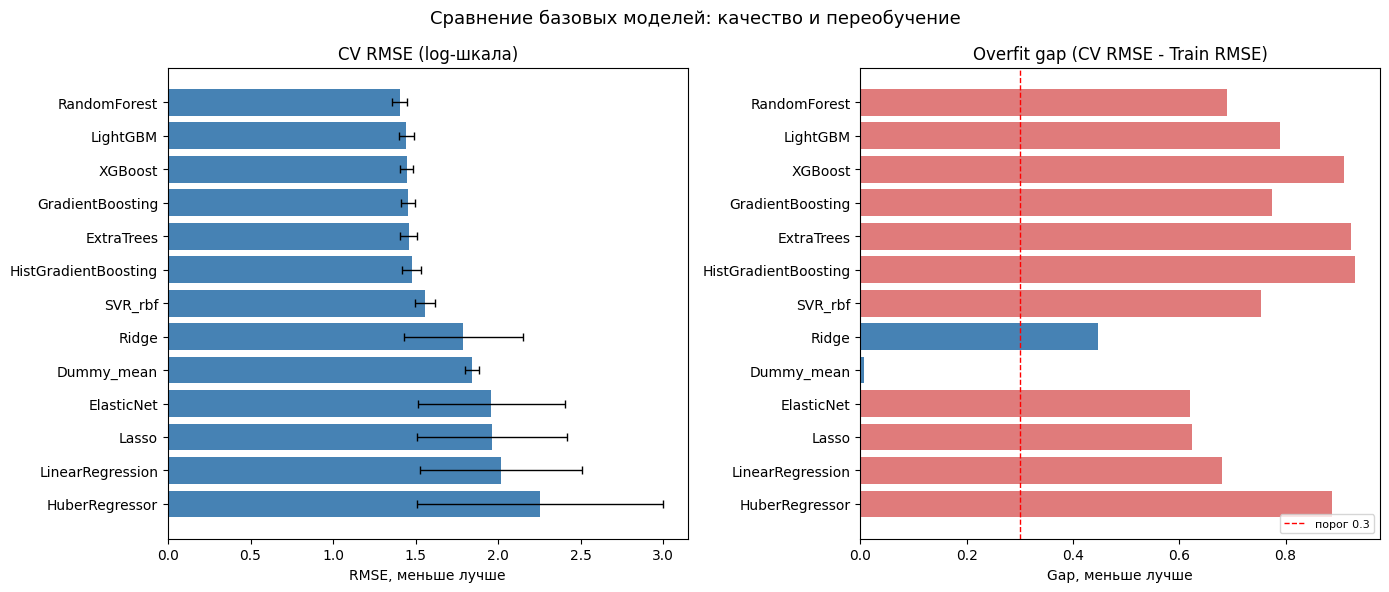

In [12]:
plot_df = cv_results.sort_values('cv_log_RMSE_mean', ascending=False)
order = plot_df['model'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(plot_df['model'], plot_df['cv_log_RMSE_mean'], color='steelblue')
axes[0].errorbar(plot_df['cv_log_RMSE_mean'], plot_df['model'],
                 xerr=plot_df['cv_log_RMSE_std'],
                 fmt='none', color='black', capsize=3, linewidth=1)
axes[0].set_title('CV RMSE (log-шкала)')
axes[0].set_xlabel('RMSE, меньше лучше')

gap_df = cv_results.set_index('model').reindex(order).reset_index()
colors = ['#e07b7b' if g > 0.5 else 'steelblue' for g in gap_df['overfit_gap_RMSE']]
axes[1].barh(gap_df['model'], gap_df['overfit_gap_RMSE'], color=colors)
axes[1].axvline(0.3, color='red', linestyle='--', linewidth=1, label='порог 0.3')
axes[1].set_title('Overfit gap (CV RMSE - Train RMSE)')
axes[1].set_xlabel('Gap, меньше лучше')
axes[1].legend(fontsize=8, loc='lower right')

plt.suptitle('Сравнение базовых моделей: качество и переобучение', fontsize=13)
plt.tight_layout()
plt.show()

## Выбор моделей для подбора гиперпараметров

По результатам кросс-валидации базовых моделей для тюнинга отобраны модели, показавшие наилучший CV RMSE среди своих групп.

RandomForest -- лучший CV RMSE среди всех моделей: log_RMSE 1.50, log_R2 0.38, original_R2 0.24. Несмотря на высокий gap (~0.68), включён в тюнинг с акцентом на ограничение глубины и увеличение min_samples_leaf.

GradientBoosting -- лучший баланс качества и переобучения среди tree-based: log_RMSE 1.51, gap ~0.75 -- наименьший среди GBM-моделей. Приоритетная модель для тюнинга через снижение learning_rate и max_depth.

XGBoost и HistGBM -- log_RMSE 1.52 и 1.57, незначительно уступая GradientBoosting. Богатый набор параметров регуляризации (reg_alpha, reg_lambda, min_samples_leaf) даёт возможность сократить переобучение при тюнинге.

SVR_rbf -- лучшая линейная модель: log_RMSE 1.63, log_R2 0.27, gap ~0.75. Чувствительна к выбору C и gamma, поэтому тюнинг оправдан.

Ridge -- единственная модель с gap < 0.5 (~0.45): log_RMSE 1.68, log_R2 0.22. Высокий std указывает на нестабильность при текущем alpha; подбор alpha через logspace позволит найти оптимальный уровень регуляризации.

ExtraTrees и LightGBM исключены из тюнинга: log_RMSE 1.53 и 1.52 при gap ~0.90 -- переобучение сопоставимо с XGBoost при худшем качестве. Линейные модели Lasso, ElasticNet, LinearRegression, HuberRegressor исключены ввиду высокой нестабильности (std > 0.4) и низкого log_R2 (0.10--0.22) относительно tree-based группы.

## Подбор гиперпараметров для лучших моделей

На этом этапе подбираются гиперпараметры для наиболее перспективных моделей. Тюнинг выполняется на train-части с кросс-валидацией, а финальная оценка -- на test-части.

Для моделей, у которых внутренний параллелизм может конфликтовать с параллелизмом RandomizedSearchCV, используется n_jobs=1. Это снижает риск перегрузки CPU и делает время выполнения более стабильным.

In [ ]:
tuning_configs = {
    'GradientBoosting_tuned': {'feature_set': 'X_tree',
                               'X_train': X_tree_train,
                               'X_test': X_tree_test,
                               'estimator': GradientBoostingRegressor(random_state=RANDOM_STATE),
                               'params': {'n_estimators':     [300, 500, 700, 1000],
                                          'max_depth':        [2, 3, 4],
                                          'learning_rate':    [0.005, 0.01, 0.03, 0.05],
                                          'min_samples_leaf': [10, 20, 30, 50],
                                          'subsample':        [0.6, 0.7, 0.8],
                                          'max_features':     [0.3, 0.4, 0.5]}},

    'RandomForest_tuned':     {'feature_set': 'X_tree',
                               'X_train': X_tree_train,
                               'X_test': X_tree_test,
                               'estimator': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
                               'params': {'n_estimators':     [300, 500, 800],
                                          'max_depth':        [4, 6, 8],
                                          'min_samples_leaf': [4, 8, 12, 20],
                                          'max_features':     [0.2, 0.3, 0.4, 0.6]}},

    'XGBoost_tuned':          {'feature_set': 'X_tree',
                               'X_train': X_tree_train,
                               'X_test': X_tree_test,
                               'estimator': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                               'params': {'n_estimators':     [300, 500, 800],
                                          'max_depth':        [3, 4, 5],
                                          'learning_rate':    [0.01, 0.03, 0.05],
                                          'subsample':        [0.6, 0.7, 0.8],
                                          'colsample_bytree': [0.5, 0.6, 0.7],
                                          'reg_alpha':        [0.1, 0.5, 1.0, 2.0],
                                          'reg_lambda':       [1.0, 2.0, 5.0, 10.0]}},

    'HistGBM_tuned':          {'feature_set': 'X_tree',
                               'X_train': X_tree_train,
                               'X_test': X_tree_test,
                               'estimator': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                               'params': {'max_iter':          [300, 500, 700],
                                          'max_depth':         [3, 4, 5],
                                          'learning_rate':     [0.01, 0.03, 0.05],
                                          'min_samples_leaf':  [20, 30, 50, 80],
                                          'l2_regularization': [0.1, 0.5, 1.0, 2.0]}},

    'SVR_tuned':              {'feature_set': 'X_linear',
                               'X_train': X_linear_train,
                               'X_test': X_linear_test,
                               'estimator': make_pipeline(StandardScaler(), SVR(kernel='rbf')),
                               'params': {'svr__C':       [3, 10, 30, 100, 300],
                                          'svr__epsilon': [0.01, 0.03, 0.05, 0.1],
                                          'svr__gamma':   ['scale', 0.001, 0.003, 0.01]}},

    'Ridge_tuned':            {'feature_set': 'X_linear',
                               'X_train': X_linear_train,
                               'X_test': X_linear_test,
                               'estimator': make_pipeline(StandardScaler(), Ridge(random_state=RANDOM_STATE)),
                               'params': {'ridge__alpha': np.logspace(-3, 3, 30)}},
}

In [ ]:
tuned_rows_cv = {}
best_models = {}

N_ITER_MAP = {
    'GradientBoosting_tuned': 100,
    'RandomForest_tuned':      80,
    'XGBoost_tuned':          100,
    'HistGBM_tuned':           80,
    'SVR_tuned':               50,
    'Ridge_tuned':             30,
}

for model_name, config in tuning_configs.items():
    search = RandomizedSearchCV(estimator=config['estimator'],
                                param_distributions=config['params'],
                                n_iter=N_ITER_MAP[model_name],
                                scoring='neg_root_mean_squared_error',
                                cv=cv,
                                random_state=RANDOM_STATE,
                                n_jobs=-1,
                                verbose=1)

    search.fit(config['X_train'], y_train)

    best_models[model_name] = search.best_estimator_

    tuned_rows_cv[model_name] = {'model':            model_name,
                                 'feature_set':      config['feature_set'],
                                 'best_cv_log_RMSE': -search.best_score_,
                                 'best_params':      search.best_params_}

tuning_results = (pd.DataFrame(tuned_rows_cv.values())
                    .sort_values('best_cv_log_RMSE')
                    .reset_index(drop=True))

display(tuning_results)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,model,feature_set,best_cv_log_RMSE,best_params
0,RandomForest_tuned,X_tree,1.397520,"{'n_estimators': 800, 'min_samples_leaf': 4, '..."
1,XGBoost_tuned,X_tree,1.399142,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alp..."
2,GradientBoosting_tuned,X_tree,1.400770,"{'subsample': 0.6, 'n_estimators': 1000, 'min_..."
3,HistGBM_tuned,X_tree,1.428334,"{'min_samples_leaf': 20, 'max_iter': 700, 'max..."
4,SVR_tuned,X_linear,1.498918,"{'svr__gamma': 'scale', 'svr__epsilon': 0.1, '..."
5,Ridge_tuned,X_linear,1.659715,{'ridge__alpha': 621.0169418915616}


## Итоговое сравнение baseline и tuned моделей

In [15]:
tuned_test_rows = [get_test_result_row(model_name=model_name,
                                       model=model,
                                       feature_set_name=tuning_configs[model_name]['feature_set'],
                                       X_train=tuning_configs[model_name]['X_train'],
                                       X_test=tuning_configs[model_name]['X_test'],
                                       refit=False)
                   for model_name, model in best_models.items()]

all_results = (pd.concat([test_results.assign(stage='baseline'),
                          pd.DataFrame([row for row, _ in tuned_test_rows])
                            .sort_values('log_RMSE')
                            .reset_index(drop=True)
                            .assign(stage='tuned')],
                         ignore_index=True)
               .sort_values('log_RMSE')
               .reset_index(drop=True))

display(all_results.round(4))

,model,feature_set,log_RMSE,log_MAE,log_MedAE,log_R2,original_RMSE,original_MAE,original_MedAE,original_R2,stage
0,GradientBoosting_tuned,X_tree,1.4371,1.1456,0.9458,0.4285,396.5131,178.7960,38.1211,0.2073,tuned
1,RandomForest_tuned,X_tree,1.4417,1.1517,0.9095,0.4248,399.5071,178.5863,32.8308,0.1952,tuned
2,XGBoost_tuned,X_tree,1.4491,1.1323,0.9087,0.4189,380.3590,175.5441,36.5467,0.2705,tuned
3,HistGBM_tuned,X_tree,1.4506,1.1632,0.9885,0.4178,396.4365,179.7204,42.4099,0.2076,tuned
4,RandomForest,X_tree,1.5019,1.1632,0.9309,0.3758,388.9903,179.1255,29.4589,0.2371,baseline
5,GradientBoosting,X_tree,1.5085,1.1905,0.9961,0.3703,377.3163,180.0766,36.2589,0.2822,baseline
6,LightGBM,X_tree,1.5187,1.1677,0.8551,0.3618,366.4625,182.1911,32.5755,0.3229,baseline
7,XGBoost,X_tree,1.5242,1.1677,0.8694,0.3572,351.4400,173.7549,32.0867,0.3772,baseline
8,ExtraTrees,X_tree,1.5280,1.1413,0.8617,0.3539,376.2575,172.6211,30.9395,0.2862,baseline
9,SVR_tuned,X_linear,1.5634,1.1939,0.8662,0.3237,390.6363,182.5703,42.3705,0.2306,tuned


In [16]:
all_results_sorted = all_results.sort_values('log_RMSE').reset_index(drop=True)

best_row_log = all_results_sorted.iloc[0]
best_row_orig = all_results.sort_values('original_R2', ascending=False).reset_index(drop=True).iloc[0]

print('Лучшая модель по log_RMSE:')
display(best_row_log.to_frame().T[['model', 'feature_set', 'log_RMSE', 'log_R2',
                                    'original_RMSE', 'original_R2', 'stage']].round(4))

print('Лучшая модель по original_R2:')
display(best_row_orig.to_frame().T[['model', 'feature_set', 'log_RMSE', 'log_R2',
                                     'original_RMSE', 'original_R2', 'stage']].round(4))

best_row = best_row_orig
best_model_name = best_row['model']
best_stage = best_row['stage']
best_feature_set = best_row['feature_set']

if best_stage == 'tuned':
    best_model = best_models[best_model_name]
else:
    best_model = fitted_baseline[best_model_name]

print(f'Используем для диагностики и сохранения: {best_model_name} (original_R2={best_row["original_R2"]:.4f})')

Лучшая модель по log_RMSE:


,model,feature_set,log_RMSE,log_R2,original_RMSE,original_R2,stage
0,GradientBoosting_tuned,X_tree,1.437058,0.428547,396.513121,0.207259,tuned


Лучшая модель по original_R2:


,model,feature_set,log_RMSE,log_R2,original_RMSE,original_R2,stage
0,XGBoost,X_tree,1.524169,0.357166,351.440039,0.377243,baseline


Используем для диагностики и сохранения: XGBoost (original_R2=0.3772)


Для дальнейшей диагностики и сохранения выбираем модель по original_R2, так как итоговая интерпретация качества IC50 выполняется в исходных единицах измерения.

## Диагностика лучшей модели

Четыре графика:
1. **Факт vs прогноз** -- насколько точны предсказания в целом;
2. **Остатки vs прогноз** -- наличие гетероскедастичности;
3. **Q-Q plot** -- нормальность распределения остатков;
4. **Остатки на исходной шкале** -- систематическая ошибка в хвосте (IC50 > 500 mM).


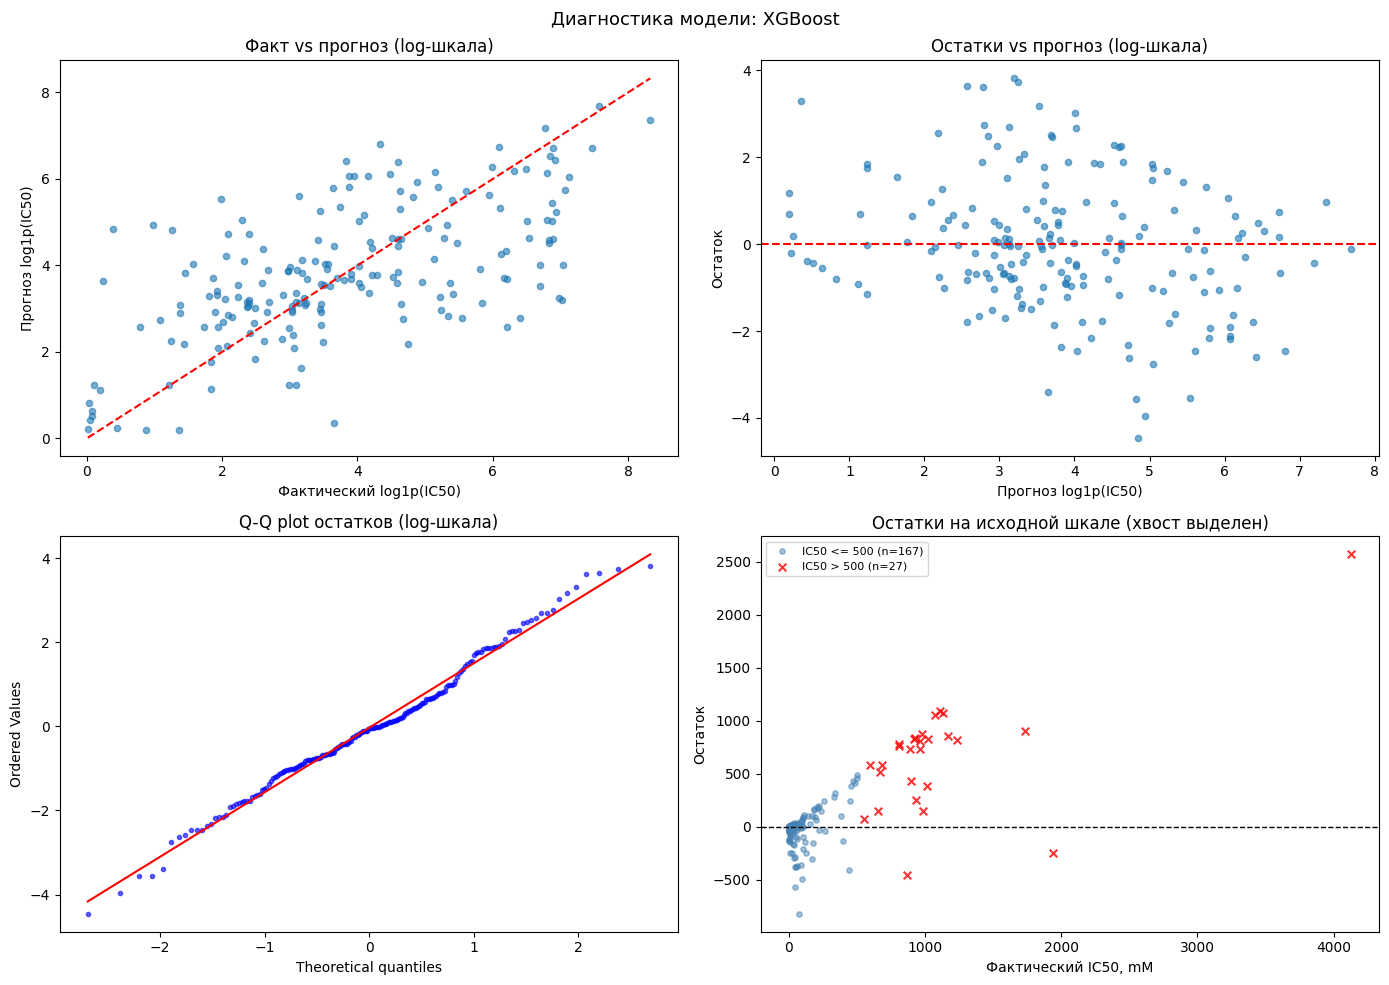

Статистика остатков (log-шкала):
  Mean:   -0.0360  (близко к 0 -- нет систематической ошибки)
  Std:    1.5277
  Skew:   0.1131
  Kurt:   0.2121
  Normaltest p-value: 0.5730  (> 0.05 -- нормальность не отвергается)

Ошибки в хвосте (IC50 > 500 mM, n=27):
  MAE: 717.74 mM
  Vs MAE по всем: 173.75 mM


In [17]:
if best_row['feature_set'] == 'X_linear':
    X_test_best = X_linear_test
else:
    X_test_best = X_tree_test

best_pred_log = best_model.predict(X_test_best)
best_pred_original = np.clip(np.expm1(best_pred_log), a_min=0, a_max=None)

residuals_log = y_test - best_pred_log
residuals_original = y_test_original - best_pred_original

_, p_norm = normaltest(residuals_log)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_test, best_pred_log, alpha=0.6, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0, 0].set_title('Факт vs прогноз (log-шкала)')
axes[0, 0].set_xlabel('Фактический log1p(IC50)')
axes[0, 0].set_ylabel('Прогноз log1p(IC50)')

axes[0, 1].scatter(best_pred_log, residuals_log, alpha=0.6, s=20)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Остатки vs прогноз (log-шкала)')
axes[0, 1].set_xlabel('Прогноз log1p(IC50)')
axes[0, 1].set_ylabel('Остаток')

probplot(residuals_log, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot остатков (log-шкала)')
axes[1, 0].get_lines()[0].set(markersize=3, alpha=0.6)

tail_mask = y_test_original.values > 500
axes[1, 1].scatter(
    y_test_original.values[~tail_mask], residuals_original.values[~tail_mask],
    alpha=0.5, s=15, label=f'IC50 <= 500 (n={(~tail_mask).sum()})', color='steelblue'
)
axes[1, 1].scatter(
    y_test_original.values[tail_mask], residuals_original.values[tail_mask],
    alpha=0.8, s=30, label=f'IC50 > 500 (n={tail_mask.sum()})', color='red', marker='x'
)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('Остатки на исходной шкале (хвост выделен)')
axes[1, 1].set_xlabel('Фактический IC50, mM')
axes[1, 1].set_ylabel('Остаток')
axes[1, 1].legend(fontsize=8)

plt.suptitle(f'Диагностика модели: {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

print('Статистика остатков (log-шкала):')
print(f'  Mean:   {residuals_log.mean():.4f}  (близко к 0 -- нет систематической ошибки)')
print(f'  Std:    {residuals_log.std():.4f}')
print(f'  Skew:   {skew(residuals_log):.4f}')
print(f'  Kurt:   {kurtosis(residuals_log):.4f}')
print(f'  Normaltest p-value: {p_norm:.4f}  (> 0.05 -- нормальность не отвергается)')

if tail_mask.sum() > 0:
    print(f'\nОшибки в хвосте (IC50 > 500 mM, n={tail_mask.sum()}):')
    print(f'  MAE: {np.abs(residuals_original.values[tail_mask]).mean():.2f} mM')
    print(f'  Vs MAE по всем: {np.abs(residuals_original).mean():.2f} mM')

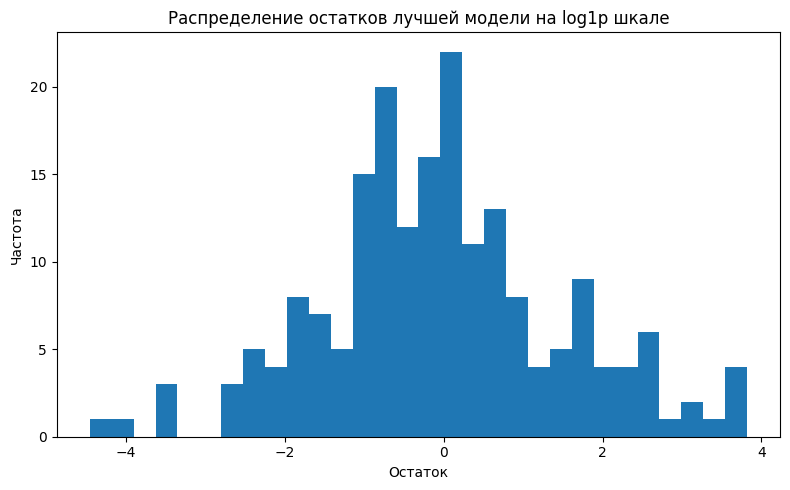

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(residuals_log, bins=30)
plt.title('Распределение остатков лучшей модели на log1p шкале')
plt.xlabel('Остаток')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()


## Важность признаков для лучшей модели

Если лучшая модель поддерживает feature_importances_, выводится топ признаков. Для линейной модели выводятся коэффициенты после pipeline-преобразований, если они доступны.

,feature,importance
0,NumSaturatedHeterocycles,0.089433
1,fr_Ar_OH,0.046095
2,VSA_EState8,0.045971
3,NHOHCount,0.043962
4,fr_NH2,0.035612
5,NumAromaticRings,0.023354
6,NumAliphaticRings,0.021731
7,fr_allylic_oxid,0.020788
8,NumAliphaticCarbocycles,0.020441
9,fr_NH1,0.017880


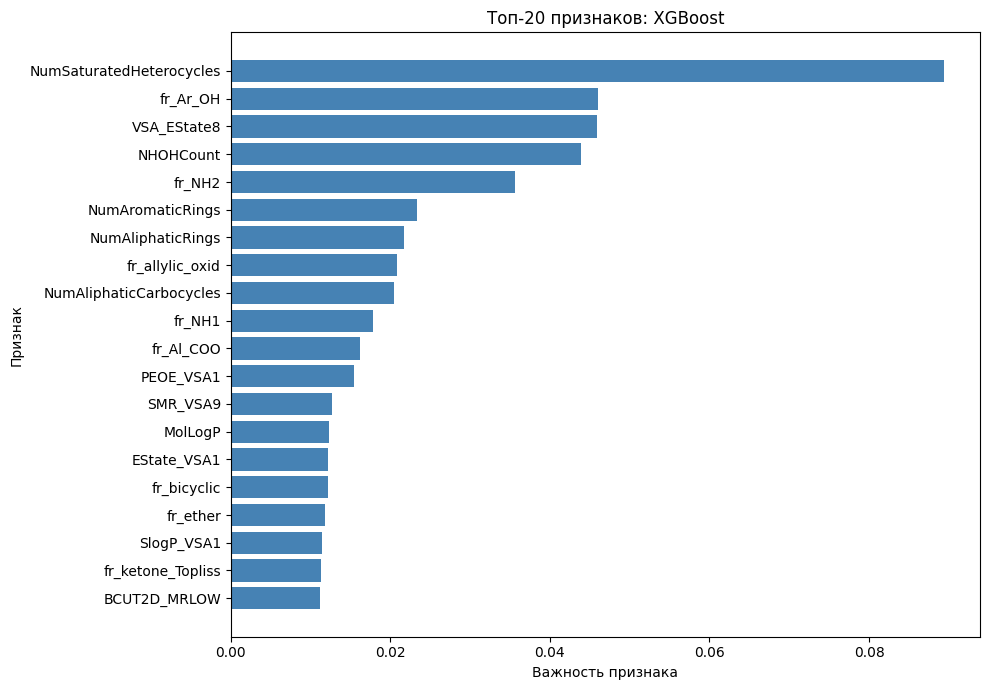

In [19]:
feature_names_best = X_linear.columns if best_feature_set == 'X_linear' else X_tree.columns

final_model = best_model[-1] if isinstance(best_model, Pipeline) else best_model

if hasattr(final_model, 'feature_importances_'):
    importance_df = (
        pd.DataFrame({
            'feature':    feature_names_best,
            'importance': final_model.feature_importances_
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

    display(importance_df.head(30))

    plot_imp = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(plot_imp['feature'], plot_imp['importance'], color='steelblue')
    plt.xlabel('Важность признака')
    plt.ylabel('Признак')
    plt.title(f'Топ-20 признаков: {best_model_name}')
    plt.tight_layout()
    plt.show()

elif hasattr(final_model, 'coef_'):
    importance_df = (
        pd.DataFrame({
            'feature':     feature_names_best,
            'coefficient': np.ravel(final_model.coef_)
        })
        .assign(abs_coefficient=lambda x: x['coefficient'].abs())
        .sort_values('abs_coefficient', ascending=False)
        .drop(columns='abs_coefficient')
        .reset_index(drop=True)
    )

    display(importance_df.head(30))

    plot_imp = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(plot_imp['feature'], plot_imp['coefficient'], color='steelblue')
    plt.xlabel('Коэффициент')
    plt.ylabel('Признак')
    plt.title(f'Топ-20 коэффициентов: {best_model_name}')
    plt.tight_layout()
    plt.show()

else:
    print(f'Модель {type(final_model).__name__} не поддерживает feature_importances_ или coef_.')


## Сохранение лучшей модели

In [20]:
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, 'best_IC50_regression_model.joblib')

joblib.dump(best_model, model_path)

print(f'Лучшая модель сохранена: {model_path}')

Лучшая модель сохранена: models/best_IC50_regression_model.joblib


## Выводы

Для регрессии IC50, mM модели обучались на логарифмированной целевой переменной log1p(IC50), так как EDA показал сильную правостороннюю асимметрию распределения IC50 (skewness = 3.80). Метрики рассчитывались как на логарифмированной шкале, так и на исходной шкале после обратного преобразования expm1.

### Сравнение моделей

Протестировано 13 базовых моделей и 6 тюнингованных моделей. Tree-based модели показали более высокое качество, чем линейные модели, но при этом демонстрировали выраженный overfit_gap_RMSE на кросс-валидации. Это ожидаемо, поскольку обучающая выборка относительно небольшая (772 наблюдения), а число признаков после preprocessing остаётся достаточно большим.

По основной метрике на логарифмированной шкале тюнинг улучшил результаты нескольких моделей: GradientBoosting_tuned снизил log_RMSE примерно с 1.508 до 1.437, XGBoost_tuned - с 1.524 до 1.449, RandomForest_tuned - с 1.502 до 1.442. Разница между лучшими tuned-моделями невелика и сопоставима с разбросом качества на кросс-валидации.

При этом на исходной шкале лучший результат по original_R2 и original_RMSE показала baseline-модель XGBoost. Это связано с тем, что тюнинг оптимизировался по log_RMSE, а эта метрика меньше штрафует ошибки на экстремально больших значениях IC50. Поэтому модель, лучшая на log-шкале, не обязательно является лучшей на исходной шкале концентрации.

Для диагностики и сохранения выбрана модель с наилучшим качеством на исходной шкале - XGBoost baseline, так как исходная шкала IC50, mM имеет практический смысл для интерпретации результата.

### Интерпретация качества

Качество финальной модели умеренное: модель объясняет часть вариации IC50, но не решает задачу идеально. Для выбранной модели получены log_R2 = 0.357 и original_R2 = 0.377 на тестовой выборке. Такой результат выглядит реалистично для задачи предсказания IC50 по RDKit-дескрипторам на небольшой выборке.

Основная проблема модели связана с правым хвостом распределения IC50. Для соединений с IC50 > 500 mM ошибка существенно выше, чем в среднем по тестовой выборке. Это показывает, что модель лучше описывает общий порядок величин, но хуже предсказывает экстремально большие значения активности.

Остатки на log-шкале близки к нормальному распределению (normaltest p = 0.573, skewness = 0.113), что подтверждает уместность логарифмирования целевой переменной. При этом небольшое систематическое смещение остатков не является критичным.

### Важность признаков

Среди важных признаков выбранной модели присутствуют химически интерпретируемые RDKit-дескрипторы, связанные с кольцевыми структурами, функциональными группами, электронными состояниями и липофильностью. Это делает результаты модели более правдоподобными, однако для строгой химической интерпретации требуется отдельный предметный анализ.

В топ признаков вошли NumSaturatedHeterocycles, fr_Ar_OH, VSA_EState8, NHOHCount, fr_NH2, NumAromaticRings, NumAliphaticRings и другие дескрипторы. При этом ни один признак не доминирует полностью, что снижает риск зависимости модели от одного случайного артефакта.

### Рекомендации

- при дальнейшем тюнинге добавить метрики исходной шкалы в процедуру выбора модели или использовать мультиметрику;
- отдельно анализировать ошибки в хвосте распределения IC50, так как именно экстремально большие значения дают наибольший вклад в ошибки на исходной шкале;
- рассмотреть дополнительные признаки, например Morgan fingerprints (ECFP4), вместе с RDKit-дескрипторами;
- при расширении выборки повторить сравнение моделей, поскольку небольшое число наблюдений остаётся главным ограничением качества;
- попробовать ансамблирование нескольких лучших моделей, например XGBoost, GradientBoosting и RandomForest, если это будет оправдано на валидации.